In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from glob import glob
import cmocean as cm
import cartopy.crs as ccrs

from utils import filt, interp_expert_to_unsmoothed

In [3]:
plt.rcParams['font.size']=10
plt.rcParams['axes.labelsize']='small'
plt.rcParams['pcolor.shading']='auto'

In [28]:
###
# SWOT data inputs
### 
region = 'browsebasin'

area = [122.5, -14.4, 123.2, -13.6] # Zoom 


x1,y1,x2,y2=area
satpass = '021' # 062 or 131

# Mode-1
cycle = '504'
sigma_min, sigma_max = -20, 20
# xlims, ylims = [122.75,123.15], [-14.35,  -13.95] # Around the mooring (large)
xlims, ylims = [122.8,123.1], [-14.3,  -14.00] # Around the moorings (small)

t1 = '2023-04-28 02:00:00'
t2 = '2023-04-28 15:00:00'
swot_time = np.datetime64('2023-04-28 10:44:22')

##
# Mode-2 
cycle = '513' # May 7
t1 = '2023-05-07 08:00:00'
t2 = '2023-05-08 02:00:00'
swot_time = np.datetime64('2023-05-07 09:20:35')

cycle = '524' # May 18
t1 = '2023-05-18 07:00:00'
t2 = '2023-05-18 22:00:00'
swot_time = np.datetime64('2023-05-18 07:36:35')

# xlims, ylims = [122.65,122.85], [-14.1,  -13.8] # NW of the moorings
# xlims, ylims = [122.60,122.85], [-14.14,  -13.8] # NW of the moorings (large)
xlims, ylims = [122.60,122.85], [-14.2,  -13.8] # NW of the moorings (large)

sigma_min, sigma_max = -5, 5




####
version = 'L2'
# sigma_min, sigma_max = -20, 20
# L2 version C
if version=='L2':
    ncfiles = sorted(glob(f'/data/SWOT/l2_karin_unsmoothed/cycle_{cycle}/*_{satpass}*.nc'))
    ncfiles_2k = sorted(glob(f'/data/SWOT/l2_karin_versionC/cycle_{cycle}/*_{satpass}*.nc'))

elif version=='L3':
    # L3 version 2.0.1
    ncfiles = sorted(glob(f'/data/SWOT/l3_karin_unsmoothed_v2_0_1/cycle_{cycle}/*_{satpass}*.nc'))

ncfiles


['/data/SWOT/l2_karin_unsmoothed/cycle_524/SWOT_L2_LR_SSH_Unsmoothed_524_021_20230518T071529_20230518T080556_PGC0_02.nc']

In [29]:
if version=='L3':

    dsall = xr.open_dataset(ncfiles[0])
    # Subsample
    ds = dsall
    selection = (
        (ds.longitude > area[0]) &
        (ds.longitude < area[2]) &
        (ds.latitude > area[1]) &
        (ds.latitude < area[3]))
    selection = selection.compute()
    ds_area = ds.where(selection, drop=True)
    ds_area
    timestr = ds_area['time'][100,100].values
    ssha = ds_area['ssha_unfiltered']
    var2 = 'sigma0'

In [30]:
def subsample_ds(ds, area):
    selection = (
        (ds.longitude > area[0]) &
        (ds.longitude < area[2]) &
        (ds.latitude > area[1]) &
        (ds.latitude < area[3]))
    selection = selection.compute()
    return ds.where(selection, drop=True)
    
if version=='L2':
    dsall = xr.open_dataset(ncfiles[0], group='left')
    # Subsample
    ds_area = subsample_ds(dsall, area)
    dsall = xr.open_dataset(ncfiles_2k[0])

    ds_area_2k = subsample_ds(dsall,area)

    var2 = 'sig0_karin_2'
    var1 = 'ssh_karin_2'
    
    # var1 = 'mean_sea_surface_cnescls'
    xin, yin = ds_area_2k['longitude'].values, ds_area_2k['latitude'].values
    xout, yout = ds_area['longitude'].values, ds_area['latitude'].values
    height_cor_xover = interp_expert_to_unsmoothed(xin, yin,
                            ds_area_2k['height_cor_xover'].values,
                            xout, yout)
    ocean_tide_fes = interp_expert_to_unsmoothed(xin, yin, ds_area_2k['ocean_tide_fes'].values, xout, yout)
    solid_earth_tide = interp_expert_to_unsmoothed(xin, yin, ds_area_2k['solid_earth_tide'].values, xout, yout)
    internal_tide_hret = interp_expert_to_unsmoothed(xin, yin, ds_area_2k['internal_tide_hret'].values, xout, yout)
    pole_tide = interp_expert_to_unsmoothed(xin, yin, ds_area_2k['pole_tide'].values, xout, yout)
    dac = interp_expert_to_unsmoothed(xin, yin, ds_area_2k['dac'].values, xout, yout)
    #ssha = ds_area[var1]*0  - xcor_unsmoothed
    ssha =  ds_area[var1] \
        + height_cor_xover \
        - ds_area['mean_sea_surface_cnescls']\
        - solid_earth_tide \
        - ocean_tide_fes \
        - internal_tide_hret\
        - pole_tide \
        - dac    
    #ssh_karin_2 - mean_sea_surface_cnescls - solid_earth_tide - ocean_tide_fes – internal_tide_hret - pole_tide - dac
    #timestr = ds_area_2k.attrs['time_coverage_start']#.replace('-','').replace(':','')
    timestr = ds_area['time'][100,100].values
    


In [31]:
### 
# Mooring inputs
###
#SWOT_NAust/DATA/mooring_sealevel_S245_v3.nc
uvdir = '/data/SWOT_Cruise/FV02/stacked_moorings_adcp'
tdir = '/data/SWOT_Cruise/FV02/stacked_moorings_tp'
etadir = '../DATA/'

sites = {}

sites.update({'W310':
              {'uvfile':f'{uvdir}/[BB23]_[BB23_REC]_[W310]_[multi(2)_nominal_instrument_height_asb]_[multi(2)_instrument_model]_[multi(2)_instrument_serial_number]_[no_outfile_append].nc',
              'tfile': f'{tdir}/[BB23]_[BB23_REC]_[W310]_[multi(27)_nominal_instrument_height_asb]_[multi(5)_instrument_model]_[multi(27)_instrument_serial_number]_[no_outfile_append].nc',
              'sig1000file':'/data/SWOT_Cruise/Signature1000/BB23_W310_VEL_BM_ENU_stacked.nc',
              'etafile': f'{etadir}/mooring_sealevel_W310_v3.nc' ,
              'z_bot':-314,
              'color':'#1f77b4',
              }
             })

sites.update({'S245':
              {'uvfile':f'{uvdir}/[BB23]_[BB23_REC]_[S245]_[5]_[Quartermaster]_[11795]_[no_outfile_append].nc',
              'tfile': f'{tdir}/[BB23]_[BB23_REC]_[S245]_[multi(35)_nominal_instrument_height_asb]_[multi(2)_instrument_model]_[multi(35)_instrument_serial_number]_[no_outfile_append].nc',
              'sig1000file':'/data/SWOT_Cruise/Signature1000/BB23_S245_VEL_BM_ENU_stacked.nc',
              'etafile': f'{etadir}/mooring_sealevel_S245_v3.nc' ,
              'z_bot':-254,
              'color':'#ff7f0e',
              }
             })

sites.update({'N280':
              {'uvfile':f'{uvdir}/[BB23]_[BB23_REC]_[N280]_[5]_[Longranger]_[24613]_[no_outfile_append].nc',
              'tfile': f'{tdir}/[BB23]_[BB23_REC]_[N280]_[multi(27)_nominal_instrument_height_asb]_[multi(3)_instrument_model]_[multi(27)_instrument_serial_number]_[no_outfile_append].nc',
              #'etafile': f'{etadir}/mooring_steric_ssh_N280_v4.nc',
              'etafile': f'{etadir}/mooring_sealevel_N280_v8.nc',
              'z_bot':-276,
              'color':'#d62728'
              }
             })



In [32]:
from gptide import cov
from gptide import GPtideScipy
from gptide.gpdask import GPtideDask

def kernel_2d_gptide(x, xpr, params):

    eta, lx, ly= params

    # Build the covariance matrix 
    # Note that gptide does a transpose before it passes each matrix
    C = cov.matern32(x[:,1,None], xpr.T[:,1,None].T, ly)
    C *= cov.matern32(x[:,0,None], xpr.T[:,0,None].T, lx)
    C *= eta**2

    return C

def isomatern32(d,l):
    """Matern 3/2 base function, -4 high frequency spectral slope"""
    fac1 = 3*d*d
    fac2 = np.sqrt(fac1)
    return (1 + fac2/l)*np.exp(-fac2/l)

def isokernel_2d_gptide(x, xpr, params):
    """
    
    """
    eta, lxy = params
    #dy = x[:,1,None] - xpr.T[:,1,None].T
    #dx = x[:,0,None] -  xpr.T[:,0,None].T
    dy = x[:,1,None] - xpr.T[:,1,None].T
    dx = x[:,0,None] -  xpr.T[:,0,None].T
    d = np.sqrt(dx*dx + dy*dy)
    # Build the covariance matrix
    C  = isomatern32(d, lxy)
    C *= eta**2

    return C

In [33]:
from scipy.signal import convolve2d

def smooth_w(uv_ds, nsmooth=5):
    F = 1/nsmooth*np.ones((nsmooth,1)) # depth only

    w=uv_ds['w'].values
    w[np.isnan(w)] = 0.0
    wf = convolve2d(w, F, mode='same')
    
    wf_ds = uv_ds['w'].copy()
    wf_ds[:] = wf

    return wf_ds

    #import geopandas as gpd
    
def plot_sites(ax, text=True):
    p4=ax.plot(123.03041737634493, -14.230653066337094,'bo', markeredgecolor='k') # S245
    p5=ax.plot(122.8370658081835, -14.13718816307405,'bo', markeredgecolor='k') # W310
    p6=ax.plot(123.02928797854348, -14.052341197573492,'bo', markeredgecolor='k') # N280
    if text:
        ax.text(123.02928797854348, -14.052341197573492+0.01,'N280')
        ax.text(123.03041737634493, -14.230653066337094+0.01,'S245')
        ax.text(122.8370658081835, -14.13718816307405+0.01,'W310')
        
def plot_swot_basemap(ax, xlims, ylims, fine_contours=False, swath=True):

    # Add bathy etc to the plot
    #basedir = '../../MNF_SWOT/GIS'
    #swathpoly = gpd.read_file("{}/SWOT_calval_Browse_overpass_swath.shp".format(basedir))
    #swathline = gpd.read_file("{}/SWOT_calval_Browse_overpass_nadir.shp".format(basedir))
    
    # Load some bathy data
    mygroup = ''
    dsall = xr.open_dataset(f'{mygroup}/data/Bathymetry/GA_WEL_NWS_250m_DEM.nc')
    dsZ = dsall.assign_coords(nx=dsall.X,ny=dsall.Y).sel(nx=slice(xlims[0],xlims[1]), ny=slice(ylims[0], ylims[1]))
    
    cbathy= ax.contour(dsZ['X'],dsZ['Y'],-dsZ['topo'],[100,200,300,400, 500],colors='k',linewidths=0.5)
    if fine_contours:
        c_= ax.contour(dsZ['X'],dsZ['Y'],-dsZ['topo'],np.arange(100,500,10),colors='c',linewidths=0.2)

    #p1=ax.plot(123.16238333,-14.23543333,'md') # BRW mooring=
    plot_sites(ax)
    #ax.text(123.16238333,-14.23543333+0.03, 'NWSBRW')
    #if swath:
    #    p2=swathpoly.plot(ax=ax, facecolor='#859101', alpha=0.25, zorder=1e6)


    ax.set_xlim(xlims)
    ax.set_ylim(ylims)
    ax.set_aspect('equal')  

    plt.clabel(cbathy, fontsize=9)
    ax.set_ylabel(r'Latitude [$^{\circ}$N]')
    ax.set_xlabel(r'Longitude [$^{\circ}$E]')

    #del swathpoly
    #del swathline
    del dsZ
    
    return cbathy

In [34]:
# Plot a site
# panel 1 sea level: eta_s, eta_b (eta_p, eta)
# panel 2 TWC T and w
# Filter the moorings
eta_f_all = {}
for mooring in ['S245', 'N280', 'W310']:
    eta_ds = xr.open_dataset(sites[mooring]['etafile'])
    eta_s = filt(eta_ds['eta_steric'], 4*3600, 60, btype='high')
    eta_ds['eta_steric'][:] = eta_s
    if 'eta_b' in list(eta_ds.keys()):
        eta_b = filt(eta_ds['eta_b'].fillna(0)-eta_ds['eta_tide_fes'].isel(lon=0),\
                     4*3600, 60, btype='high')
        eta_ds['eta_b'][:] = eta_b

    eta_f_all.update({mooring:eta_ds})

def plot_mooring_filt(mooring, t1,t2, ax1, ax2, c, offset=0):
    eta_ds2 = eta_f_all[mooring].sel(time=slice(t1,t2))
    uv_ds = xr.open_dataset(sites[mooring]['uvfile']).sel(time=slice(t1,t2))
    t_ds =  xr.open_dataset(sites[mooring]['tfile']).sel(time=slice(t1,t2))
    
    cbar_kwargs = {"shrink": 0.3, 
                   "pad":-0.14, 
                   #"anchor":(0.5, 0.8), 
                   "orientation":'horizontal',
                   'label':r'w [m/s]',
                   "ticks":[-0.1, 0.1],}
    
    
    (eta_ds2['eta_steric']+offset).plot(c=c,lw=0.5,ax=ax1)
    if 'eta_b' in list(eta_ds2.keys()):
        (eta_ds2['eta_b']+offset).plot(c=c,ls='--',lw=0.5, ax=ax1)
    
    ####
    t_ds['Temperature'].plot.contour(ax=ax2, levels=np.arange(8,31,2), 
                                     colors='k', linewidths=0.5)
    cbar_kwargs={}
    plot_kwargs = dict(
        cmap="PuOr",
        vmin=-0.1,
        vmax=0.1,
        add_colorbar=False,
        ax=ax2,
        cbar_kwargs=cbar_kwargs,
    )

    w_s = smooth_w(uv_ds)
    c=w_s.plot(**plot_kwargs)
    # c=uv_ds['w'].plot(**plot_kwargs)

    #c.colorbar.ax.set_xlabel(r'w [m/s]', labelpad=1)
    
    ax1.set_xlabel('')
    ax1.set_xticklabels([])
    #ax1.set_ylabel('')
    ax2.set_ylabel('Depth [m]')
    ax2.set_xlabel('')

    #ax1.set_yticklabels([])
    #ax2.set_yticklabels([])

    ax1.set_xlim(eta_ds2.time[0],eta_ds2.time[-1])
    ax1.set_title('')
    ax2.set_title('')
    ax1.set_ylim(-0.15,0.15)
    ax2.set_ylim(-310,0)
    ax1.grid(True, ls=':')

    return c

def plot_mooring(mooring, t1,t2, ax1, ax2, c, offset=0):
    eta_ds = xr.open_dataset(sites[mooring]['etafile']).sel(time=slice(t1,t2))
    uv_ds = xr.open_dataset(sites[mooring]['uvfile']).sel(time=slice(t1,t2))
    t_ds =  xr.open_dataset(sites[mooring]['tfile']).sel(time=slice(t1,t2))
    
    cbar_kwargs = {"shrink": 0.3, 
                   "pad":-0.14, 
                   #"anchor":(0.5, 0.8), 
                   "orientation":'horizontal',
                   'label':r'w [m/s]',
                   "ticks":[-0.1, 0.1],}
    
    
    
    (eta_ds['eta_steric']+offset).plot(c=c,lw=0.5,ax=ax1)
    if 'eta_b' in list(eta_ds.keys()):
        (eta_ds['eta_b']-eta_ds['eta_tide_fes']+offset).plot(c=c,ls='--',lw=0.5, ax=ax1)
    
    ####
    t_ds['Temperature'].plot.contour(ax=ax2, levels=np.arange(8,31,2), 
                                     colors='k', linewidths=0.5)
    cbar_kwargs={}
    plot_kwargs = dict(
        cmap="PuOr",
        vmin=-0.1,
        vmax=0.1,
        add_colorbar=False,
        cbar_kwargs=cbar_kwargs,
    )

    w_s = smooth_w(uv_ds)
    c=w_s.plot(**plot_kwargs)
    # c=uv_ds['w'].plot(**plot_kwargs)

    #c.colorbar.ax.set_xlabel(r'w [m/s]', labelpad=1)
    
    ax1.set_xlabel('')
    ax1.set_xticklabels([])
    #ax1.set_ylabel('')
    ax2.set_ylabel('Depth [m]')
    ax2.set_xlabel('')

    #ax1.set_yticklabels([])
    #ax2.set_yticklabels([])

    ax1.set_xlim(eta_ds.time[0],eta_ds.time[-1])
    ax1.set_title('')
    ax2.set_title('')
    ax1.set_ylim(-0.4,0.6)
    ax2.set_ylim(-310,0)
    ax1.grid(True, ls=':')

    return c

def make_figure(t1,t2,swot_time,
               fig, ax1, ax2, ax3, ax4):
    #fig = plt.figure(figsize=(5,8))
    #ax1=plt.subplot2grid((4,1), (0,0), rowspan=1)
    #ax2=plt.subplot2grid((4,1), (1,0), rowspan=1)
    #ax3=plt.subplot2grid((4,1), (2,0), rowspan=1)
    #ax4=plt.subplot2grid((4,1), (3,0), rowspan=1)

    #c=plot_mooring('W310', t1, t2, ax1, ax2, sites['W310']['color'], offset=0.2)
    c=plot_mooring_filt('W310', t1, t2, ax1, ax2, sites['W310']['color'], offset=0.05)
    
    #plot_mooring('N280', t1, t2, ax1, ax3, sites['N280']['color'], offset=-0)
    plot_mooring_filt('N280', t1, t2, ax1, ax3, sites['N280']['color'], offset=-0.0)
    
    #c=plot_mooring('S245', t1, t2, ax1, ax4, sites['S245']['color'], offset=-0.2)
    c=plot_mooring_filt('S245', t1, t2, ax1, ax4, sites['S245']['color'], offset=-0.05)

    ax2.set_xticklabels([])
    ax3.set_xticklabels([])
    
    ax1.legend((r'$\eta_s^\prime$ W310',r'$\eta_b^\prime$ W310',
               r'$\eta_s^\prime$ N280',r'$\eta_b^\prime$ N280',
                r'$\eta_s^\prime$ S245',r'$\eta_b^\prime$ S245'
               ), fontsize=8, loc=(0.01,0.9), ncols=3)
    
    # ax1.legend((r'$\eta_s$ W310',r'$\eta_b$ W310',
    #            r'$\eta_s$ N280',r'$\eta_b$ N280',
    #             r'$\eta_s$ S245',r'$\eta_b$ S245'
    #            ), fontsize=8, loc=(0.01,0.9), ncols=3)
    
    ax1.set_ylabel('SSHA [m]')
    ax1.vlines(swot_time, ymin=-.4, ymax=0.6, color='k', ls='--', lw=1.5)
    ax2.vlines(swot_time, ymin=-310, ymax=0, color='k', ls='--', lw=1.5)
    ax3.vlines(swot_time, ymin=-310, ymax=0, color='k', ls='--', lw=1.5)
    ax4.vlines(swot_time, ymin=-310, ymax=0, color='k', ls='--', lw=1.5)
    
    font = {'family': 'serif',
                'color':  'k',
                'weight': 'normal',
                'size': 8,
                }
    
    cbaxes = ax4.inset_axes([0.3,0.18,0.25,0.07])
    cb=plt.colorbar(c, orientation='horizontal', cax=cbaxes)
    cb.set_ticks([-0.1,0.1])
    cb.ax.set_title('w [m/s]', fontdict=font)
    
    ax1.text(0.05,0.05,'(c)', transform=ax1.transAxes)
    ax2.text(0.05,0.05,'(d) W310', transform=ax2.transAxes)
    ax3.text(0.05,0.05,'(e) N280', transform=ax3.transAxes)
    ax4.text(0.05,0.05,'(f) S245', transform=ax4.transAxes)
    
    plt.subplots_adjust(hspace=0.05, wspace=0)
    
    # outfile = f'../FIGURES/all_mooring_w_eta_{t1}_{t2}_highpass.png'
    # plt.savefig(outfile)
    # print(outfile)
    
#plt.tight_layout()

In [35]:
%%time

data = ssha.values.ravel()
    
lon = ds_area['longitude'].values
lat = ds_area['latitude'].values
M,N = lon.shape

nanidx = ~np.isnan(data)

yd = data[nanidx]
Xm = np.array([lat.ravel(), lon.ravel()]).T # Final grid
X_ = np.array([lat.ravel()[nanidx], lon.ravel()[nanidx]]).T

numobs = yd.shape[0]

Ngp = 5000
idx = np.sort(np.random.randint(0, numobs, size=Ngp))

X = X_[idx,:]
y = yd[idx]


η_R = 0.05
ℓ_R = 5.
noise = 0.05

# covparams = [η_R, ℓ_R, ℓ_R]
# covfunc = kernel_2d_gptide

covparams = [η_R, ℓ_R]
covfunc = isokernel_2d_gptide


#GP = GPtideScipy(X, Xm, noise, covfunc, covparams)

GP = GPtideDask(X, Xm, noise, covfunc, covparams, chunksize=1000)
#yd = ds_area['sigma0'].values.ravel()[nanidx]
#data_f = np.zeros([M,N])
#data_f = GP(y[:,None]).reshape([M,N]) #

data = ds_area[var2].values.ravel()
yd = data[nanidx]
y = yd[idx]
sigma_f = GP(y[:,None]).compute().reshape([M,N])

data = ssha.values.ravel()
yd = data[nanidx]
y = yd[idx]
ssha_f = GP(y[:,None]).compute().reshape([M,N])


CPU times: user 34.4 s, sys: 37.1 s, total: 1min 11s
Wall time: 9.39 s


../FIGURES/swot_L2_w_all_mooring_w_eta_2023-05-18 07:00:00_2023-05-18 22:00:00_highpass.png


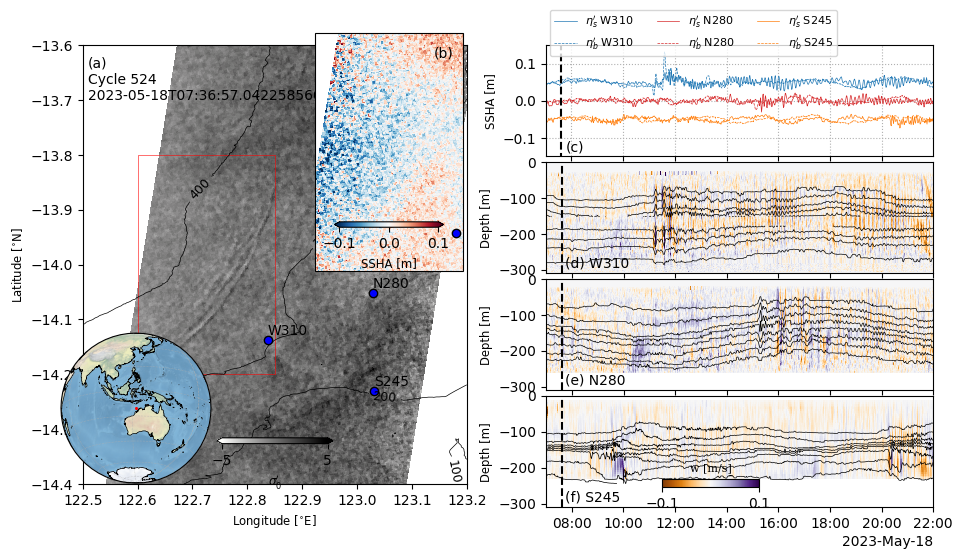

In [36]:
# var1 = 'ssha_unedited'
#var1 = 'ssha_unfiltered'

cbar_kwargs = {"shrink": 0.3, "pad":-0.10, 
               #"anchor":(0.5, 0.8), 
               "orientation":'horizontal',
               'label':r'$\sigma_0^{\prime}$',
              "ticks":[sigma_min, sigma_max],}

# fig, ax1 = plt.subplots(1, 1, figsize=(5,7))
fig = plt.figure(figsize=(11,6))
ax1 = plt.subplot2grid((4,2),(0,0), rowspan=4)

# ax1.set_title(ds_area.attrs['time_coverage_start'])
ax1.set_title(timestr)
# var2 = 'sigma0'

plot_kwargs = dict(
    x="longitude",
    y="latitude",
    cmap="cmo.gray_r",
    #cmap='bone_r',
    vmin=sigma_min,
    vmax=sigma_max,
    alpha=1,
    cbar_kwargs=cbar_kwargs)

(ds_area[var2]-sigma_f).plot.pcolormesh(ax=ax1, **plot_kwargs)

mapproj = ccrs.Orthographic(123.0, -14)

ax2 = fig.add_axes([0.24,0.53,0.33,0.37], projection=mapproj)

xbox = [xlims[0], xlims[1],xlims[1], xlims[0], xlims[0]]
ybox = [ylims[0], ylims[0], ylims[1], ylims[1], ylims[0]]
ax2.set_xlim(xlims)
ax2.set_ylim(ylims)

cbar_kwargs = {"shrink": 0.3, "pad":-0.22, 
               #"anchor":(0.5, 0.8), 
               "orientation":'horizontal',
               'label':r'SSHA [m]',
              "ticks":[-0.1, 0, 0.1],}

plot_kwargs = dict(
    x="longitude",
    y="latitude",
    cmap="RdBu_r",
    vmin=-0.10,
    vmax=0.10,
    cbar_kwargs=cbar_kwargs,)

(ssha-ssha_f).plot.pcolormesh(ax=ax2, **plot_kwargs)

# var2 = 'sigma0'
# plot_kwargs = dict(
#     x="longitude",
#     y="latitude",
#     cmap="cmo.gray",
#     #cmap='bone_r',
#     vmin=-20,
#     vmax=20,
#     alpha=1,
#     add_colorbar=False)

#(ds_area[var2]-sigma_f).plot.pcolormesh(ax=ax2, **plot_kwargs)

ax1.plot(xbox, ybox,
         color='r', linewidth=0.4, marker='',
         )

ax1.set_aspect('equal')
ax1.set_xlim(x1,x2)
ax1.set_ylim(y1,y2)
ax2.set_aspect('equal')

plot_swot_basemap(ax1, [x1,x2], [y1,y2], fine_contours=False)
plot_sites(ax2, text=False)
###
mapproj = ccrs.Orthographic(123.0, -14)
extent = [100,160,-45,0]
# extent = [0,180,-90,90]

ax3 = fig.add_axes([0.05,0.15,0.25,0.25], projection=mapproj)

ax3.gridlines(lw=0.4, ls=':')
ax3.coastlines(resolution='50m', lw=0.5)
ax3.stock_img()

#ax.fill(xybox[:,0],xybox[:,1],transform=mapproj)
#ax2.plot(0,0,'ro',transform=mapproj)

# ax3.plot(xbox, ybox,
#          color='r', linewidth=0.4, marker='',
#          transform=ccrs.Geodetic(), #remove this line to get straight lines
#          )
ax3.plot(x1,y1, 'rs', ms=1)

#.replace('-','').replace(':','')
ax1.text(122.51, -13.7,f'(a)\nCycle {cycle}\n{timestr}', fontdict={'fontsize':10})
ax2.text(0.8,0.9,f'(b)', transform=ax2.transAxes, fontdict={'fontsize':10})

# ax3.set_extent(extent)
# plt.tight_layout()

####
#
####
# outfile = f'../FIGURES/SWOT_sigma0_SSH_NLIW_{region}_{satpass}_{cycle}.png'
# plt.savefig(outfile, dpi=150)
# outfile

ax4=plt.subplot2grid((4,2), (0,1), rowspan=1)
ax5=plt.subplot2grid((4,2), (1,1), rowspan=1)
ax6=plt.subplot2grid((4,2), (2,1), rowspan=1)
ax7=plt.subplot2grid((4,2), (3,1), rowspan=1)


make_figure(t1,t2, swot_time,
           fig, ax4, ax5, ax6, ax7)

plt.subplots_adjust(wspace=0.2)

outfile = f'../FIGURES/swot_{version}_w_all_mooring_w_eta_{t1}_{t2}_highpass.png'
plt.savefig(outfile, dpi=150)
print(outfile)